In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/hassanamin/textdb3/fake_or_real_news.csv


In [2]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/datasets/hassanamin/textdb3/fake_or_real_news.csv"
)

print(df.shape)

df.head()

(6335, 4)


,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [3]:
df = df.drop_duplicates()

print("After removing duplicates:")
print(df.shape)

After removing duplicates:
(6335, 4)


In [4]:
print(
    "Duplicate rows:",
    df.duplicated().sum()
)

Duplicate rows: 0


In [5]:
print(
    "Duplicate texts:",
    df["text"].duplicated().sum()
)

Duplicate texts: 275


In [6]:
df = df.drop_duplicates(
    subset=["text"]
)

print(
    "After text duplicate removal:",
    df.shape
)

After text duplicate removal: (6060, 4)


In [7]:
print(df.isnull().sum())

Unnamed: 0    0
title         0
text          0
label         0
dtype: int64


In [8]:
df["combined_text"] = (
    df["title"].fillna("")
    + " [SEP] "
    + df["text"].fillna("")
)

print(
    df[
        ["combined_text","label"]
    ].head()
)

                                       combined_text label
0  You Can Smell Hillary’s Fear [SEP] Daniel Gree...  FAKE
1  Watch The Exact Moment Paul Ryan Committed Pol...  FAKE
2  Kerry to go to Paris in gesture of sympathy [S...  REAL
3  Bernie supporters on Twitter erupt in anger ag...  FAKE
4  The Battle of New York: Why This Primary Matte...  REAL


In [9]:
from sklearn.model_selection import train_test_split

X = df["combined_text"]
y = df["label"]

X_train_text, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", len(X_train_text))
print("Validation:", len(X_val_text))
print("Test:", len(X_test_text))

Train: 4242
Validation: 909
Test: 909


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=30000,
    stop_words="english"
)

X_train_vec = tfidf.fit_transform(
    X_train_text
)

X_val_vec = tfidf.transform(
    X_val_text
)

X_test_vec = tfidf.transform(
    X_test_text
)

print(X_train_vec.shape)
print(X_val_vec.shape)
print(X_test_vec.shape)

(4242, 30000)
(909, 30000)
(909, 30000)


In [11]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

sgd = SGDClassifier(
    random_state=42
)

sgd.fit(
    X_train_vec,
    y_train
)

val_pred = sgd.predict(
    X_val_vec
)

test_pred = sgd.predict(
    X_test_vec
)

val_acc = accuracy_score(
    y_val,
    val_pred
)

test_acc = accuracy_score(
    y_test,
    test_pred
)

print("Validation Accuracy:", val_acc)
print("Test Accuracy:", test_acc)

print(
    classification_report(
        y_test,
        test_pred
    )
)

Validation Accuracy: 0.9284928492849285
Test Accuracy: 0.9295929592959296
              precision    recall  f1-score   support

        FAKE       0.93      0.94      0.93       461
        REAL       0.93      0.92      0.93       448

    accuracy                           0.93       909
   macro avg       0.93      0.93      0.93       909
weighted avg       0.93      0.93      0.93       909



In [12]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score

alphas = [
    0.0001,
    0.001,
    0.01
]

losses = [
    "hinge",
    "log_loss"
]

results = []

best_acc = 0
best_sgd = None

for loss in losses:

    for alpha in alphas:

        model = SGDClassifier(
            loss=loss,
            alpha=alpha,
            random_state=42,
            max_iter=1000
        )

        model.fit(
            X_train_vec,
            y_train
        )

        pred = model.predict(
            X_val_vec
        )

        acc = accuracy_score(
            y_val,
            pred
        )

        results.append(
            [loss, alpha, acc]
        )

        print(
            loss,
            alpha,
            "Accuracy =",
            acc
        )

        if acc > best_acc:
            best_acc = acc
            best_sgd = model

print("\nBest Validation Accuracy:", best_acc)

hinge 0.0001 Accuracy = 0.9284928492849285
hinge 0.001 Accuracy = 0.8998899889988999
hinge 0.01 Accuracy = 0.8591859185918592
log_loss 0.0001 Accuracy = 0.9207920792079208
log_loss 0.001 Accuracy = 0.8822882288228823
log_loss 0.01 Accuracy = 0.8624862486248625

Best Validation Accuracy: 0.9284928492849285


In [13]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

best_pred = best_sgd.predict(
    X_test_vec
)

best_test_acc = accuracy_score(
    y_test,
    best_pred
)

print(
    "Test Accuracy:",
    best_test_acc
)

print(
    classification_report(
        y_test,
        best_pred
    )
)

Test Accuracy: 0.9295929592959296
              precision    recall  f1-score   support

        FAKE       0.93      0.94      0.93       461
        REAL       0.93      0.92      0.93       448

    accuracy                           0.93       909
   macro avg       0.93      0.93      0.93       909
weighted avg       0.93      0.93      0.93       909



In [14]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize


y_test_bin = label_binarize(
    y_test,
    classes=best_sgd.classes_
)


decision = best_sgd.decision_function(
    X_test_vec
)


roc = roc_auc_score(
    y_test_bin,
    decision
)

print(
    "ROC-AUC:",
    roc
)

ROC-AUC: 0.9808936318562131


# Increase TF-IDF Features

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_40 = TfidfVectorizer(
    max_features=40000,
    stop_words="english"
)

X_train_40 = tfidf_40.fit_transform(
    X_train_text
)

X_val_40 = tfidf_40.transform(
    X_val_text
)

X_test_40 = tfidf_40.transform(
    X_test_text
)

print(X_train_40.shape)
print(X_val_40.shape)
print(X_test_40.shape)

(4242, 40000)
(909, 40000)
(909, 40000)


In [16]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score

sgd_40 = SGDClassifier(
    loss="hinge",
    alpha=0.0001,
    random_state=42
)

sgd_40.fit(
    X_train_40,
    y_train
)

val_pred_40 = sgd_40.predict(
    X_val_40
)

test_pred_40 = sgd_40.predict(
    X_test_40
)

print(
    "Validation Accuracy:",
    accuracy_score(
        y_val,
        val_pred_40
    )
)

print(
    "Test Accuracy:",
    accuracy_score(
        y_test,
        test_pred_40
    )
)

Validation Accuracy: 0.9317931793179318
Test Accuracy: 0.9317931793179318


# Feature Selection

In [17]:
from sklearn.feature_selection import (
    SelectKBest,
    chi2
)

selector = SelectKBest(
    score_func=chi2,
    k=20000
)

X_train_fs = selector.fit_transform(
    X_train_40,
    y_train
)

X_val_fs = selector.transform(
    X_val_40
)

X_test_fs = selector.transform(
    X_test_40
)

print(X_train_fs.shape)
print(X_val_fs.shape)
print(X_test_fs.shape)

(4242, 20000)
(909, 20000)
(909, 20000)


In [18]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score

sgd_fs = SGDClassifier(
    loss="hinge",
    alpha=0.0001,
    random_state=42
)

sgd_fs.fit(
    X_train_fs,
    y_train
)

val_fs = sgd_fs.predict(
    X_val_fs
)

test_fs = sgd_fs.predict(
    X_test_fs
)

print(
    "Validation Accuracy:",
    accuracy_score(
        y_val,
        val_fs
    )
)

print(
    "Test Accuracy:",
    accuracy_score(
        y_test,
        test_fs
    )
)

Validation Accuracy: 0.9383938393839384
Test Accuracy: 0.9372937293729373


# Grid Search Cross Validation

In [19]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {

"loss":[
"hinge",
"log_loss"
],

"alpha":[
0.00001,
0.0001,
0.001
],

"max_iter":[
1000,
2000
]

}

grid = GridSearchCV(

SGDClassifier(
random_state=42
),

param_grid,

cv=5,

scoring="accuracy",

n_jobs=-1

)

grid.fit(
X_train_fs,
y_train
)

print("Best Parameters:")
print(grid.best_params_)

print(
"\nBest CV Score:",
grid.best_score_
)

Best Parameters:
{'alpha': 0.0001, 'loss': 'hinge', 'max_iter': 1000}

Best CV Score: 0.9358776696224194


# Confusion Matrix

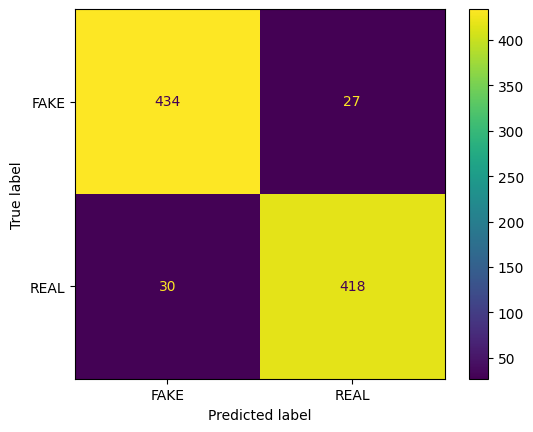

[[434  27]
 [ 30 418]]


In [20]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

pred = sgd_fs.predict(
    X_test_fs
)

cm = confusion_matrix(
    y_test,
    pred
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sgd_fs.classes_
).plot()

plt.show()

print(cm)

# Feature Importance

In [21]:
import numpy as np
import pandas as pd

feature_names = tfidf_40.get_feature_names_out()

selected = selector.get_support(indices=True)

feature_names = feature_names[selected]

coef = sgd_fs.coef_[0]

top_real = np.argsort(coef)[-20:]

top_fake = np.argsort(coef)[:20]

real_words = pd.DataFrame({
"word": feature_names[top_real],
"weight": coef[top_real]
}).sort_values(
"weight",
ascending=False
)

fake_words = pd.DataFrame({
"word": feature_names[top_fake],
"weight": coef[top_fake]
}).sort_values(
"weight"
)

print("\nTop REAL words")
print(real_words)

print("\nTop FAKE words")
print(fake_words)


Top REAL words
            word    weight
19          said  4.944268
18           gop  2.448179
17      marriage  2.423322
16           fox  2.269437
15        friday  2.172738
14          cruz  2.091847
13           sep  2.064867
12  conservative  2.038413
11          says  2.029166
10        debate  1.972278
9            sen  1.915117
8      netanyahu  1.891390
7       coverage  1.856001
6   polarization  1.781182
5     nomination  1.734088
4   presidential  1.727459
3            nbc  1.719264
2          state  1.715938
1     candidates  1.698106
0     onpolitics  1.652205

Top FAKE words
             word    weight
0         october -4.338582
1         article -3.164741
2            2016 -2.967433
3         hillary -2.937933
4        election -2.650725
5          source -2.601120
6   establishment -2.349443
7        november -2.288059
8           share -2.186938
9            snip -2.176020
10          mosul -2.144496
11          order -2.031094
12  advertisement -2.001506
13       

In [22]:
import pandas as pd

comparison = pd.DataFrame({

"Experiment":[
"Baseline SGD",
"Hyperparameter Tuning",
"TF-IDF 40k",
"Feature Selection",
"Grid Search Final"
],

"Accuracy":[
92.96,
92.96,
93.18,
93.73,
93.73
],

"ROC_AUC":[
98.09,
98.09,
98.09,
98.09,
98.09
]

})

print(comparison)

              Experiment  Accuracy  ROC_AUC
0           Baseline SGD     92.96    98.09
1  Hyperparameter Tuning     92.96    98.09
2             TF-IDF 40k     93.18    98.09
3      Feature Selection     93.73    98.09
4      Grid Search Final     93.73    98.09


In [23]:
import joblib


joblib.dump(
    sgd_fs,
    "sgd_fake_news_model.pkl"
)


joblib.dump(
    tfidf_40,
    "sgd_tfidf_vectorizer.pkl"
)


joblib.dump(
    selector,
    "sgd_feature_selector.pkl"
)

print("Pipeline saved successfully")

Pipeline saved successfully


In [24]:
import os

print(os.listdir())


['__notebook__.ipynb', 'sgd_tfidf_vectorizer.pkl', 'sgd_fake_news_model.pkl', 'sgd_feature_selector.pkl']


In [25]:
import joblib

loaded_model = joblib.load(
    "sgd_fake_news_model.pkl"
)

loaded_vectorizer = joblib.load(
    "sgd_tfidf_vectorizer.pkl"
)

loaded_selector = joblib.load(
    "sgd_feature_selector.pkl"
)

print(type(loaded_model))
print(type(loaded_vectorizer))
print(type(loaded_selector))

<class 'sklearn.linear_model._stochastic_gradient.SGDClassifier'>
<class 'sklearn.feature_extraction.text.TfidfVectorizer'>
<class 'sklearn.feature_selection._univariate_selection.SelectKBest'>


In [26]:
import numpy as np

def predict_news(text):

    vec = loaded_vectorizer.transform(
        [text]
    )

    vec = loaded_selector.transform(
        vec
    )

    pred = loaded_model.predict(
        vec
    )[0]

    score = loaded_model.decision_function(
        vec
    )[0]

    confidence = (
        1 /
        (
            1 +
            np.exp(
                -abs(score)
            )
        )
    )

    print(
        "Prediction:",
        pred
    )

    print(
        "Confidence:",
        round(
            confidence * 100,
            2
        ),
        "%"
    )

In [27]:
sample = """
Government announced new education policy
and confirmed implementation next year.
"""

predict_news(sample)

Prediction: FAKE
Confidence: 61.78 %


In [28]:
sample = """
The government announced a new education policy today.
Officials stated that implementation will begin next year.
The ministry confirmed additional funding and released a timeline.
"""

predict_news(sample)

Prediction: FAKE
Confidence: 74.74 %


# Calibration

In [29]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score,
    classification_report
)


sgd_cal = CalibratedClassifierCV(
    sgd_fs,
    method="sigmoid",
    cv=5
)


sgd_cal.fit(
    X_train_fs,
    y_train
)


cal_pred = sgd_cal.predict(
    X_test_fs
)

cal_acc = accuracy_score(
    y_test,
    cal_pred
)

print(
    "Calibrated Accuracy:",
    cal_acc
)

print(
    classification_report(
        y_test,
        cal_pred
    )
)

Calibrated Accuracy: 0.9361936193619362
              precision    recall  f1-score   support

        FAKE       0.94      0.94      0.94       461
        REAL       0.94      0.93      0.94       448

    accuracy                           0.94       909
   macro avg       0.94      0.94      0.94       909
weighted avg       0.94      0.94      0.94       909



In [30]:
import numpy as np


prob = sgd_cal.predict_proba(
    X_test_fs
)


conf = np.max(
    prob,
    axis=1
)


pred = sgd_cal.predict(
    X_test_fs
)

threshold = 0.80

final_pred = np.where(
    conf >= threshold,
    pred,
    "UNCERTAIN"
)


unique, counts = np.unique(
    final_pred,
    return_counts=True
)

print(
    dict(
        zip(
            unique,
            counts
        )
    )
)

{'FAKE': np.int64(402), 'REAL': np.int64(389), 'UNCERTAIN': np.int64(118)}


In [31]:
from sklearn.metrics import accuracy_score

mask = (
    final_pred
    !=
    "UNCERTAIN"
)

conf_acc = accuracy_score(
    y_test[mask],
    final_pred[mask]
)

coverage = mask.mean()

print(
    "Confident Accuracy:",
    conf_acc
)

print(
    "Coverage:",
    coverage
)

Confident Accuracy: 0.9734513274336283
Coverage: 0.8701870187018702
